In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

**Load the Dataset**

In [ ]:
df = pd.read_csv('property (1).csv')
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Price
0,1360,2,3,1953,7860,3.039481e+05
1,4272,3,3,1997,5292,8.603863e+05
2,3592,4,1,1983,9723,7.343898e+05
3,966,6,1,1903,4086,2.264488e+05
4,4926,6,4,1944,1081,1.022486e+06


**Define Feature Sets**

Created five different combinations of independent variables (features).           
Each combination removes one feature so you can compare how important each variable is.

In [ ]:

# List of feature combinations
feature_sets = [
    ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size'],   # Model 1
    ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built'],              # Model 2
    ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Lot_Size'],                # Model 3
    ['Square_Footage', 'Num_Bedrooms', 'Year_Built', 'Lot_Size'],                   # Model 4
    ['Square_Footage', 'Num_Bathrooms', 'Year_Built', 'Lot_Size']                   # Model 5
]

**Selected the Target Variable**

Set Price as the dependent variable.

In [ ]:
target = 'Price'

**Initialize Results Storage**

Created an empty list called results to store MSE and R² scores for each model.

In [ ]:
results = []

**Training and Evaluating Multiple Linear Regression Models**

This step loops through each feature combination to train a separate Linear Regression model, generate predictions, compute performance metrics, and store the results for comparison.

In [ ]:
# Train models
for i, features in enumerate(feature_sets):
    print("\nTraining Model", i+1, "with features:", features)

    X = df[features]
    y = df[target]

    # Perform train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Train Linear Regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2_train = model.score(X_train, y_train)
    r2_test = r2_score(y_test, y_pred)

    # Save results
    results.append({
        'Model': f'Model {i+1}',
        'Features Used': ', '.join(features),
        'Number of Features': len(features),
        'MSE': mse,
        'Train_R2': r2_train,
        'Test_R2': r2_test
    })

    # Print model details
    print(f"\nModel {i+1} Coefficients:")
    coef_table = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_})
    print(coef_table)
    print(f"Train R²: {r2_train:.4f}")
    print(f"Test R²: {r2_test:.4f}")
    print(f"MSE: {mse:.4f}")


Training Model 1 with features: ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size']

Model 1 Coefficients:
          Feature  Coefficient
0  Square_Footage   200.009974
1    Num_Bedrooms  4978.224346
2   Num_Bathrooms  3031.264046
3      Year_Built   -99.730392
4        Lot_Size     0.100939
Train R²: 0.9941
Test R²: 0.9941
MSE: 399518741.6800

Training Model 2 with features: ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built']

Model 2 Coefficients:
          Feature  Coefficient
0  Square_Footage   200.010330
1    Num_Bedrooms  4978.611147
2   Num_Bathrooms  3031.460264
3      Year_Built   -99.720686
Train R²: 0.9941
Test R²: 0.9941
MSE: 399615514.7689

Training Model 3 with features: ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Lot_Size']

Model 3 Coefficients:
          Feature  Coefficient
0  Square_Footage   200.009279
1    Num_Bedrooms  4979.483227
2   Num_Bathrooms  3031.379392
3        Lot_Size     0.099177
Train R²: 0.9939
Test 

**Creating and Displaying the Final Model Comparison Table**

Converting all stored model performance results into a DataFrame and print it, allowing for an organized comparison of each model’s metrics.

In [ ]:
results_df = pd.DataFrame(results)
print("\nFinal Model Comparison:")
print(results_df)



Final Model Comparison:
     Model                                      Features Used  \
0  Model 1  Square_Footage, Num_Bedrooms, Num_Bathrooms, Y...   
1  Model 2  Square_Footage, Num_Bedrooms, Num_Bathrooms, Y...   
2  Model 3  Square_Footage, Num_Bedrooms, Num_Bathrooms, L...   
3  Model 4  Square_Footage, Num_Bedrooms, Year_Built, Lot_...   
4  Model 5  Square_Footage, Num_Bathrooms, Year_Built, Lot...   
5  Model 1  Square_Footage, Num_Bedrooms, Num_Bathrooms, Y...   
6  Model 2  Square_Footage, Num_Bedrooms, Num_Bathrooms, Y...   
7  Model 3  Square_Footage, Num_Bedrooms, Num_Bathrooms, L...   
8  Model 4  Square_Footage, Num_Bedrooms, Year_Built, Lot_...   
9  Model 5  Square_Footage, Num_Bathrooms, Year_Built, Lot...   

   Number of Features           MSE  Train_R2   Test_R2  
0                   5  3.995187e+08  0.994119  0.994128  
1                   4  3.996155e+08  0.994118  0.994126  
2                   4  4.122522e+08  0.993938  0.993941  
3                   4  4.10

**Sorting Models by Test R-squared Score**

This step sorts the model comparison table in descending order of Test R² to rank the models from best to worst performance and resets the index for a clean layout.

In [ ]:
results_df_sorted = results_df.sort_values(by='Test_R2', ascending=False).reset_index(drop=True)

**Visualizing Model Performance Using Bar Charts**

Generated two bar charts : -

*   One for Test R² and
*   One for MSE by using Seaborn






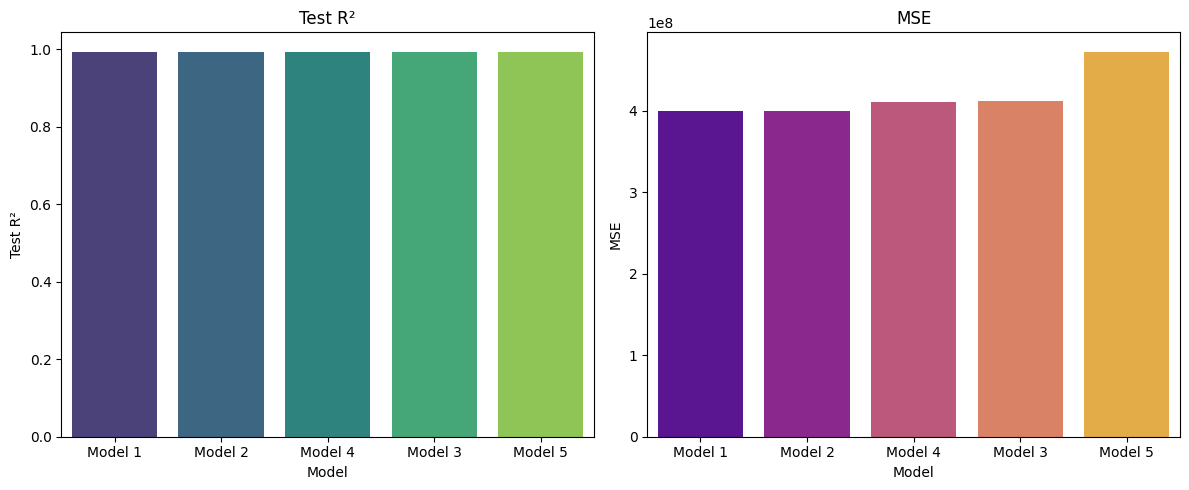

In [ ]:
plt.figure(figsize=(12, 5))

# --- Test R² Plot ---
plt.subplot(1, 2, 1)
sns.barplot(
    x='Model',
    y='Test_R2',
    hue='Model',
    data=results_df_sorted,
    palette='viridis',
    legend=False
)
plt.title('Test R²')
plt.xlabel('Model')
plt.ylabel('Test R²')

# --- MSE Plot ---
plt.subplot(1, 2, 2)
sns.barplot(
    x='Model',
    y='MSE',
    hue='Model',
    data=results_df_sorted,
    palette='plasma',
    legend=False
)
plt.title('MSE')
plt.xlabel('Model')
plt.ylabel('MSE')

plt.tight_layout()
plt.show()


**Reflective Summary :  Linear Regression Model Comparison**

**Feature Selection Choices**

In this exercise, the dependent variable selected was Price, as the objective was to predict house prices based on property characteristics. Five different combinations of independent variables were tested. The first model included all five features to establish a baseline. Subsequent models removed one feature at a time to analyze the impact of each variable on prediction performance. This systematic elimination approach helped in understanding the importance of individual predictors such as lot size, number of bedrooms, and year built.

**Observations from Model Comparisons**

The results showed that the model including all five features achieved the highest R-squared value (~0.994), indicating excellent predictive performance. Removing features led to a slight decrease in R-squared values. Notably, removing the number of bathrooms resulted in the most significant performance drop, suggesting it has strong predictive importance. Overall, the models demonstrated high accuracy, indicating a strong linear relationship between the selected features and property price.

**Challenges Faced and Solutions**

One challenge was ensuring proper data splitting to avoid overfitting. This was resolved by using an 80/20 train-test split with a fixed random state for reproducibility. Another challenge was interpreting the meaning of R-squared values and understanding how feature removal affects model performance. By systematically comparing models and reviewing evaluation metrics such as MSE and R², this issue was clarified. Additionally, formatting feature combinations clearly for comparison required careful coding.

**Insights Gained**

This exercise reinforced the importance of feature selection in machine learning. Even though all models performed well, the inclusion of all relevant features improved prediction accuracy. The experiment demonstrated that removing important predictors can significantly impact model performance. It also highlighted how R-squared is a useful metric for evaluating regression models. Overall, the activity strengthened understanding of Multiple Linear Regression, model evaluation, and the practical importance of feature engineering in predictive analytics.

**Final Conclusion**



*   Multiple Linear Regression works effectively for predicting property prices.
*   Feature selection directly impacts prediction accuracy.
*   R² comparison helps identify the best-performing model.
*   All features together provided optimal performance.





In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import _message
import json

content = _message.blocking_request('get_ipynb')['ipynb']

with open('Week3_Group25_SakshiHasurkar.ipynb', 'w') as f:
    json.dump(content, f)

In [ ]:
!pip install nbconvert
!jupyter nbconvert --to html Week3_Group25_SakshiHasurkar.ipynb

[NbConvertApp] Converting notebook Week3_Group25_SakshiHasurkar.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 344942 bytes to Week3_Group25_SakshiHasurkar.html


In [ ]:
from google.colab import files
files.download("Week3_Group25_SakshiHasurkar.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>